Using device: cuda


Epoch 1/10 - Train Loss: 0.3085, Val Loss: 0.2648, Val IoU: 0.5897, LR: 0.000100
✅ Best model updated (IoU 0.5897)


Epoch 2/10 - Train Loss: 0.2668, Val Loss: 0.2441, Val IoU: 0.6167, LR: 0.000100
✅ Best model updated (IoU 0.6167)
🔓 Backbone unfrozen, fine-tuning full model!


Epoch 3/10 - Train Loss: 0.2488, Val Loss: 0.2480, Val IoU: 0.6404, LR: 0.000100
✅ Best model updated (IoU 0.6404)


Epoch 4/10 - Train Loss: 0.2231, Val Loss: 0.2542, Val IoU: 0.6536, LR: 0.000100
✅ Best model updated (IoU 0.6536)


...

Epoch 8/10 - Train Loss: 0.1289, Val Loss: 0.3169, Val IoU: 0.7016, LR: 0.000050


Epoch 9/10 - Train Loss: 0.1205, Val Loss: 0.3281, Val IoU: 0.7154, LR: 0.000050
✅ Best model updated (IoU 0.7154)


Epoch 10/10 - Train Loss: 0.1145, Val Loss: 0.3602, Val IoU: 0.7116, LR: 0.000050
💾 Final model saved as deeplabv3_final.pth


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 167/167 [01:53<00:00,  1.48it/s]


Mean IoU: 0.7116, Mean Dice: 0.8246, Pixel Accuracy: 0.8496


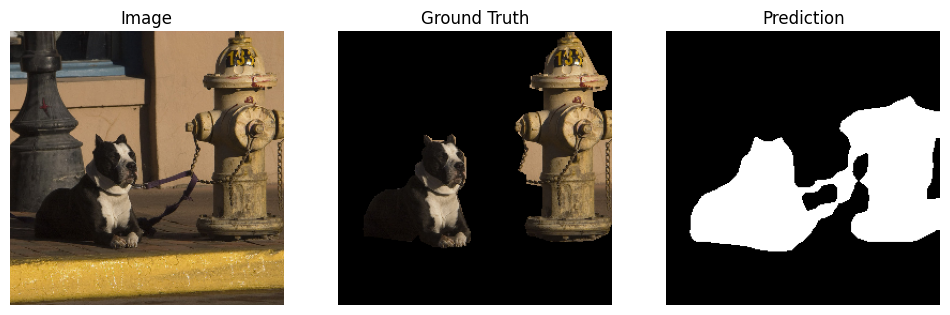

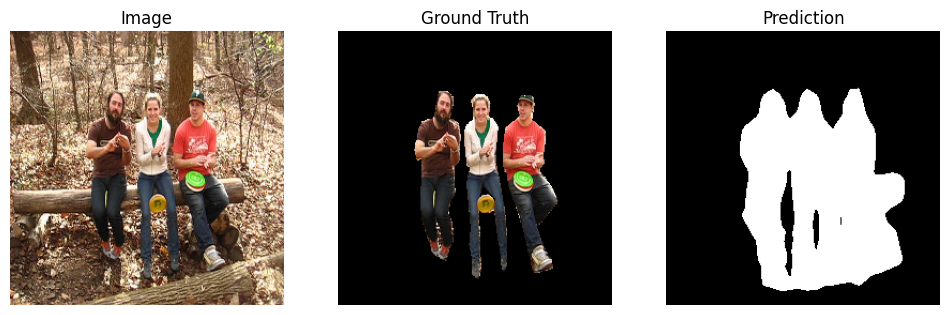

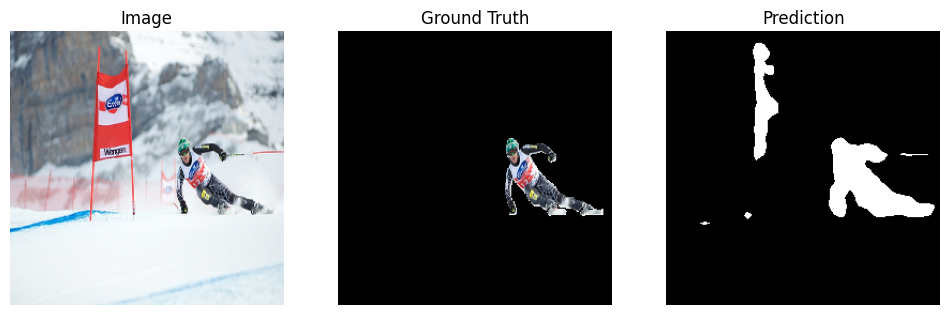

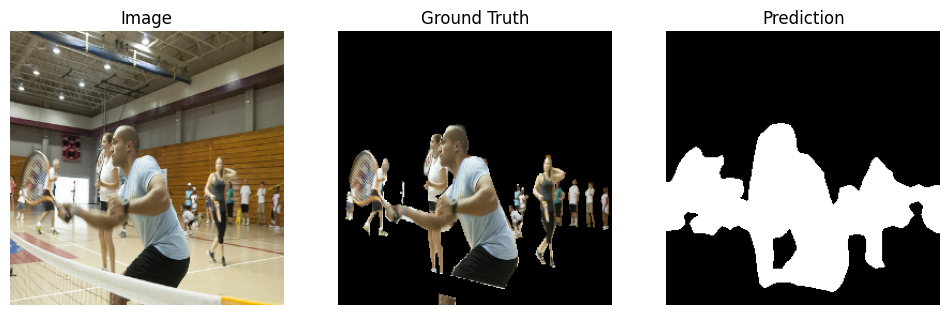

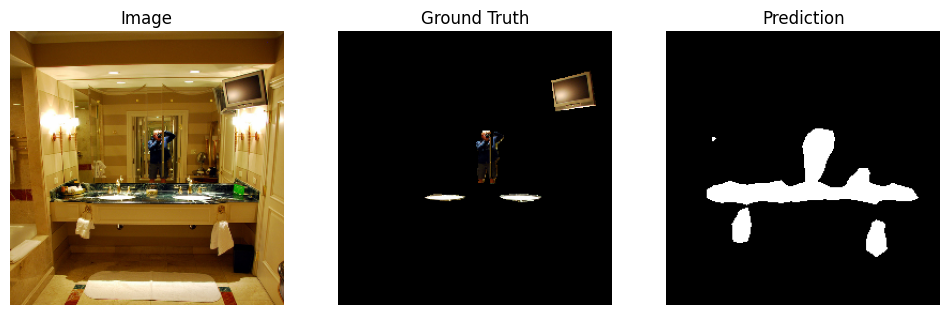

In [11]:
import os
import json
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from skimage.draw import polygon
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================
# Config & Device
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_epochs = 10
batch_size = 6
learning_rate = 1e-4
weight_decay = 1e-5
patience = 6
num_classes = 2
image_size = 256

# ======================
# Dataset
# ======================
class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.transform = transform
        with open(annotations_path, "r") as f:
            coco = json.load(f)
        self.images = {img["id"]: img["file_name"] for img in coco["images"]}
        self.annotations = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_id = list(self.images.keys())[idx]
        img_path = os.path.join(self.images_path, self.images[img_id])
        img = np.array(Image.open(img_path).convert("RGB"))
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        anns = self.annotations.get(img_id, [])
        for ann in anns:
            for seg in ann["segmentation"]:
                if isinstance(seg, list) and len(seg) % 2 == 0:
                    poly = np.array(seg).reshape(-1, 2)
                    rr, cc = polygon(poly[:, 1], poly[:, 0], shape=img.shape[:2])
                    mask[rr, cc] = 1
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]
        return img, mask.long()

# ======================
# Transforms
# ======================
train_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ======================
# Dataset & Loaders
# ======================
images_path = r"D:\val2017\val2017"
annotations_path = r"D:\annotations_trainval2017\annotations\instances_val2017.json"

dataset = CocoMaskedDataset(images_path, annotations_path, transform=train_transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# ======================
# Model
# ======================
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
model.to(device)

class_weights = torch.tensor([0.1, 0.9]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ======================
# Metrics
# ======================
def iou_score(preds, masks, num_classes=num_classes):
    preds = torch.argmax(preds, dim=1)
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        ious.append((intersection / union).item() if union != 0 else float('nan'))
    return np.nanmean(ious)

def dice_score(preds, masks, num_classes=num_classes):
    preds = torch.argmax(preds, dim=1)
    dices = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)
        intersection = (pred_inds & target_inds).sum().float() * 2
        denominator = pred_inds.sum().float() + target_inds.sum().float()
        dices.append((intersection / denominator).item() if denominator != 0 else float('nan'))
    return np.nanmean(dices)

def pixel_accuracy(preds, masks):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == masks).sum().float()
    total = torch.numel(masks)
    return (correct / total).item()

# ======================
# Training
# ======================
def train_model(model, train_loader, val_loader, num_epochs=num_epochs, patience=patience):
    best_val_iou = 0.0
    patience_counter = 0
    backbone_frozen = True
    best_model_wts = None
    
    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Training]", leave=False):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        
        # === Validation ===
        model.eval()
        val_loss = 0
        val_ious = []
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Validation]", leave=False):
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)["out"]
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                val_ious.append(iou_score(outputs, masks))
        avg_val_loss = val_loss / len(val_loader)
        avg_val_iou = np.mean(val_ious)
        
        print(f"Epoch {epoch}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_val_iou:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # === Save best checkpoint by IoU ===
        if avg_val_iou > best_val_iou:
            best_val_iou = avg_val_iou
            best_model_wts = model.state_dict()
            torch.save(best_model_wts, "deeplabv3_best.pth")
            print(f"✅ Best model updated (IoU {best_val_iou:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
        
        # === Unfreeze backbone ===
        if backbone_frozen and epoch >= 2:
            for param in model.backbone.parameters():
                param.requires_grad = True
            print("🔓 Backbone unfrozen, fine-tuning full model!")
            backbone_frozen = False
        
        scheduler.step()
        if patience_counter >= patience:
            print("⏹️ Early stopping triggered!")
            break
    
    # === Save final epoch model ===
    torch.save(model.state_dict(), "deeplabv3_final.pth")
    print("💾 Final model saved as deeplabv3_final.pth")
    
    if best_model_wts:
        model.load_state_dict(best_model_wts)
    return model

# ======================
# Evaluation
# ======================
def evaluate_model(model, dataloader):
    model.eval()
    metrics = {"IoU": [], "Dice": [], "PixelAcc": []}
    with torch.no_grad():
        for imgs, masks in tqdm(dataloader, desc="Evaluating"):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            metrics["IoU"].append(iou_score(outputs, masks))
            metrics["Dice"].append(dice_score(outputs, masks))
            metrics["PixelAcc"].append(pixel_accuracy(outputs, masks))
    print(f"Mean IoU: {np.mean(metrics['IoU']):.4f}, Mean Dice: {np.mean(metrics['Dice']):.4f}, Pixel Accuracy: {np.mean(metrics['PixelAcc']):.4f}")

# ======================
# Visualization
# ======================
def visualize_predictions(model, dataloader, num_samples=5):
    model.eval()
    samples = 0
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)["out"]
            preds = torch.argmax(outputs, dim=1).cpu()
            for i in range(imgs.size(0)):
                img = imgs[i].cpu().permute(1, 2, 0).numpy()
                img = np.clip(img * (0.229,0.224,0.225) + (0.485,0.456,0.406), 0, 1)
                mask_gt = masks[i].cpu().numpy()
                mask_pred = preds[i].numpy()

                gt_overlay = img.copy()
                gt_overlay[mask_gt == 0] = 0

                fig, axs = plt.subplots(1, 3, figsize=(12,4))
                axs[0].imshow(img); axs[0].set_title("Image"); axs[0].axis("off")
                axs[1].imshow(gt_overlay); axs[1].set_title("Ground Truth"); axs[1].axis("off")
                axs[2].imshow(mask_pred, cmap="gray"); axs[2].set_title("Prediction"); axs[2].axis("off")
                plt.show()
                
                samples += 1
                if samples >= num_samples:
                    return

# ======================
# Run Training
# ======================
trained_model = train_model(model, train_loader, val_loader)
evaluate_model(trained_model, val_loader)
visualize_predictions(trained_model, val_loader, num_samples=5)


In [7]:
import os

if os.path.exists("deeplabv3_best.pth"):
    print("✅ Model file found!")
else:
    print("❌ Model file not found.")


✅ Model file found!


C:\Users\puliu\AppData\Local\Temp\ipykernel_25376\4259509226.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=d

✅ Model loaded from deeplabv3_final.pth


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 834/834 [13:01<00:00,  1.07it/s]


Mean IoU: 0.7834, Mean Dice: 0.8741, Pixel Accuracy: 0.8947


Visualizing:   0%|                                                                             | 0/834 [00:00<?, ?it/s]

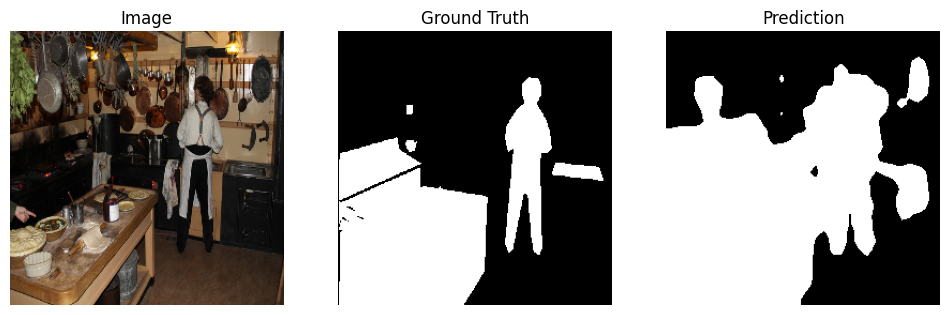

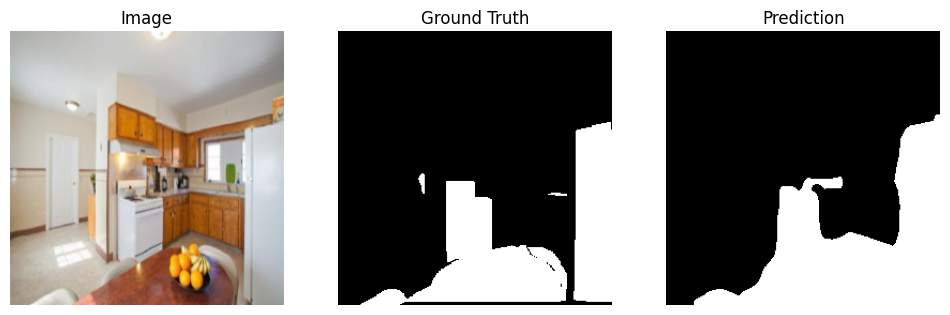

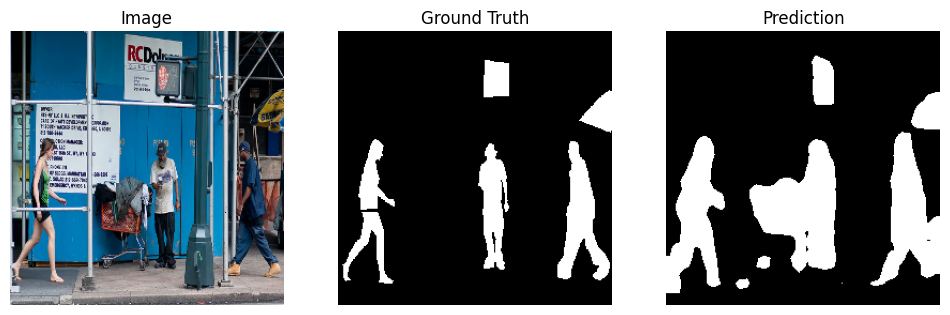

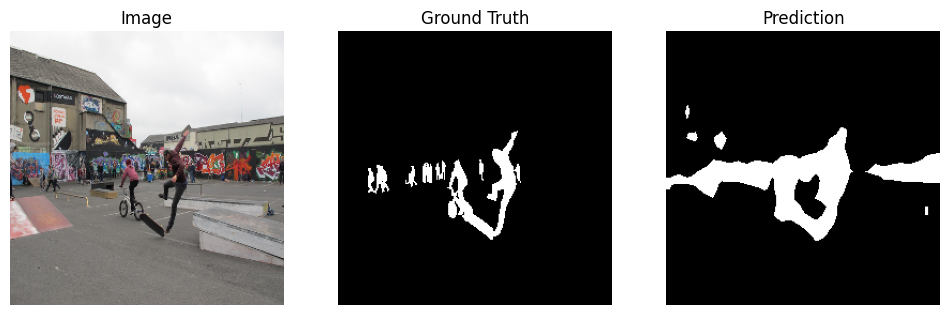

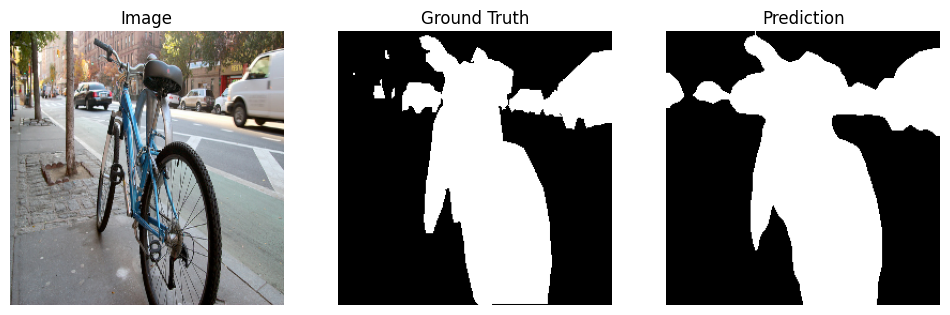

Visualizing:   0%|                                                                             | 0/834 [00:04<?, ?it/s]


In [4]:
import os
import json
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from skimage.draw import polygon
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================
# Config
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 2
image_size = 256
batch_size = 6
model_path = "deeplabv3_final.pth"   # or "deeplabv3_best.pth"

images_path = r"D:\val2017\val2017"
annotations_path = r"D:\annotations_trainval2017\annotations\instances_val2017.json"

# ======================
# Dataset
# ======================
class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.transform = transform
        with open(annotations_path, "r") as f:
            coco = json.load(f)
        self.images = {img["id"]: img["file_name"] for img in coco["images"]}
        self.annotations = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_id = list(self.images.keys())[idx]
        img_path = os.path.join(self.images_path, self.images[img_id])
        img = np.array(Image.open(img_path).convert("RGB"))
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        anns = self.annotations.get(img_id, [])
        for ann in anns:
            for seg in ann["segmentation"]:
                if isinstance(seg, list) and len(seg) % 2 == 0:
                    poly = np.array(seg).reshape(-1, 2)
                    rr, cc = polygon(poly[:, 1], poly[:, 0], shape=img.shape[:2])
                    mask[rr, cc] = 1
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]
        return img, mask.long()

# ======================
# Transforms
# ======================
val_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ======================
# DataLoader (Validation only)
# ======================
dataset = CocoMaskedDataset(images_path, annotations_path, transform=val_transform)
val_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# ======================
# Reload Model
# ======================
model = deeplabv3_resnet50(weights=None, aux_loss=True)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print(f"✅ Model loaded from {model_path}")

# ======================
# Evaluation
# ======================
def iou_score(preds, masks, num_classes=num_classes):
    preds = torch.argmax(preds, dim=1)
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        ious.append((intersection / union).item() if union != 0 else float('nan'))
    return np.nanmean(ious)

def dice_score(preds, masks, num_classes=num_classes):
    preds = torch.argmax(preds, dim=1)
    dices = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)
        intersection = (pred_inds & target_inds).sum().float() * 2
        denominator = pred_inds.sum().float() + target_inds.sum().float()
        dices.append((intersection / denominator).item() if denominator != 0 else float('nan'))
    return np.nanmean(dices)

def pixel_accuracy(preds, masks):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == masks).sum().float()
    total = torch.numel(masks)
    return (correct / total).item()

def evaluate_model(model, dataloader):
    model.eval()
    metrics = {"IoU": [], "Dice": [], "PixelAcc": []}
    with torch.no_grad():
        for imgs, masks in tqdm(dataloader, desc="Evaluating", leave=True):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)["out"]
            metrics["IoU"].append(iou_score(outputs, masks))
            metrics["Dice"].append(dice_score(outputs, masks))
            metrics["PixelAcc"].append(pixel_accuracy(outputs, masks))
    print(f"Mean IoU: {np.mean(metrics['IoU']):.4f}, "
          f"Mean Dice: {np.mean(metrics['Dice']):.4f}, "
          f"Pixel Accuracy: {np.mean(metrics['PixelAcc']):.4f}")

# ======================
# Visualization
# ======================
def visualize_predictions(model, dataloader, num_samples=5):
    model.eval()
    samples = 0
    with torch.no_grad():
        for imgs, masks in tqdm(dataloader, desc="Visualizing", leave=True):
            imgs = imgs.to(device)
            outputs = model(imgs)["out"]
            preds = torch.argmax(outputs, dim=1).cpu()
            for i in range(imgs.size(0)):
                img = imgs[i].cpu().permute(1, 2, 0).numpy()
                img = np.clip(img * (0.229,0.224,0.225) + (0.485,0.456,0.406), 0, 1)
                mask_gt = masks[i].cpu().numpy()
                mask_pred = preds[i].numpy()

                fig, axs = plt.subplots(1, 3, figsize=(12,4))
                axs[0].imshow(img); axs[0].set_title("Image"); axs[0].axis("off")
                axs[1].imshow(mask_gt, cmap="gray"); axs[1].set_title("Ground Truth"); axs[1].axis("off")
                axs[2].imshow(mask_pred, cmap="gray"); axs[2].set_title("Prediction"); axs[2].axis("off")
                plt.show()

                samples += 1
                if samples >= num_samples:
                    return

# ======================
# Run Evaluation + Visualization
# ======================
evaluate_model(model, val_loader)
visualize_predictions(model, val_loader, num_samples=5)
